# SCIONA Build Status - Consistent Evaluation

This notebook analyses the JSON reports in `reports/` with two constraints:

- every aggregation states its effective coverage
- consistency checks are kept separate from descriptive summaries

It is intentionally additive: it does not depend on or reinterpret `evaluation.ipynb`.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.4f}".format)

PALETTE = [
    "#4477AA",
    "#EE7733",
    "#228833",
    "#AA3377",
    "#66CCEE",
    "#CCBB44",
    "#7B66D2",
    "#000000",
    "#999999",
    "#332288",
]

LANG_COLORS = {
    "python": "#4477AA",
    "typescript": "#EE7733",
    "javascript": "#228833",
    "java": "#7B66D2",
    "other": "#999999",
}

BOOLEAN_CMAP = ListedColormap(["#D0D7DE", "#4477AA"])


In [2]:
REPORTS_DIR = Path("reports")
REPORT_FILES = sorted(REPORTS_DIR.glob("*.json"))

reports = {}
for path in REPORT_FILES:
    with path.open() as f:
        reports[path.stem] = json.load(f)

REPOS = sorted(reports)
print(f"Loaded {len(REPOS)} reports: {REPOS}")


Loaded 10 reports: ['airbyte', 'axios', 'commons-lang', 'fastapi', 'guava', 'nest', 'pydantic', 'sympy', 'vscode', 'webpack']


## 1. Report inventory and schema coverage

This section records versions, language coverage, and where scope breakdown is unavailable.


In [3]:
inventory_rows = []
scope_inventory_rows = []
for repo, report in reports.items():
    summary = report["summary"]
    langs = summary["languages"]
    inventory_rows.append({
        "repo": repo,
        "schema_version": report.get("schema_version"),
        "status_report_version": report.get("status_report_version"),
        "tool_version": report.get("tool_version"),
        "created_at": summary.get("created_at"),
        "snapshot_id": summary.get("snapshot_id"),
        "artifact_db_available": summary.get("artifact_db_available"),
        "language_count": len(langs),
        "languages": ", ".join(sorted(lang["language"] for lang in langs)),
        "languages_missing_scope_breakdown": sum(lang.get("call_site_funnel_by_scope") is None for lang in langs),
    })
    for lang in langs:
        scope_inventory_rows.append({
            "repo": repo,
            "language": lang["language"],
            "files": lang["files"],
            "nodes": lang["nodes"],
            "callsite_pairs": lang["callsite_pairs"]["count"],
            "scope_breakdown_available": lang.get("call_site_funnel_by_scope") is not None,
        })

inventory_df = pd.DataFrame(inventory_rows).sort_values("repo").set_index("repo")
scope_inventory_df = pd.DataFrame(scope_inventory_rows).sort_values(["repo", "language"]).reset_index(drop=True)

inventory_df


,schema_version,status_report_version,tool_version,created_at,snapshot_id,artifact_db_available,language_count,languages,languages_missing_scope_breakdown
repo,,,,,,,,,
airbyte,1.0,1,1.0.0,2026-03-13T20:24:24.736950+00:00,93b007d0441b1d5d2cd74f0231a51a228454a408cf78ec...,True,4,"java, javascript, python, typescript",0
axios,1.0,1,1.0.0,2026-03-13T20:25:57.114947+00:00,cad556337bcde75053c145f7ee399809f393ea80bcb673...,True,2,"javascript, typescript",1
commons-lang,1.0,1,1.0.0,2026-03-13T20:26:14.074950+00:00,1b31d23af02dd1a48d261a94d34244f1ac0a819ce68afd...,True,1,java,0
fastapi,1.0,1,1.0.0,2026-03-13T20:26:47.233528+00:00,93b8eef40f4117fca1eac25bc7397263d988c7b916a816...,True,2,"javascript, python",0
guava,1.0,1,1.0.0,2026-03-13T20:27:17.348738+00:00,0540ba1d87621453a27ad9b1664b4ec0e2f2ea88d42b74...,True,2,"java, javascript",1
nest,1.0,1,1.0.0,2026-03-13T20:29:17.739580+00:00,e496c2ebda9ea47c65abe97544bc89e0335a4f7d8f1d21...,True,2,"javascript, typescript",0
pydantic,1.0,1,1.0.0,2026-03-13T20:29:45.001908+00:00,245d5326ed348def34c6e8d9163c016b6967ab5e06410b...,True,2,"javascript, python",0
sympy,1.0,1,1.0.0,2026-03-13T20:31:19.263227+00:00,113bcd9593064be749a526adbe2a51ceae2ff90960dfa3...,True,1,python,0
vscode,1.0,1,1.0.0,2026-03-13T20:34:13.301648+00:00,f76c03fe1e627cd3a97028fc7085619b028a9d036d0e91...,True,4,"java, javascript, python, typescript",2


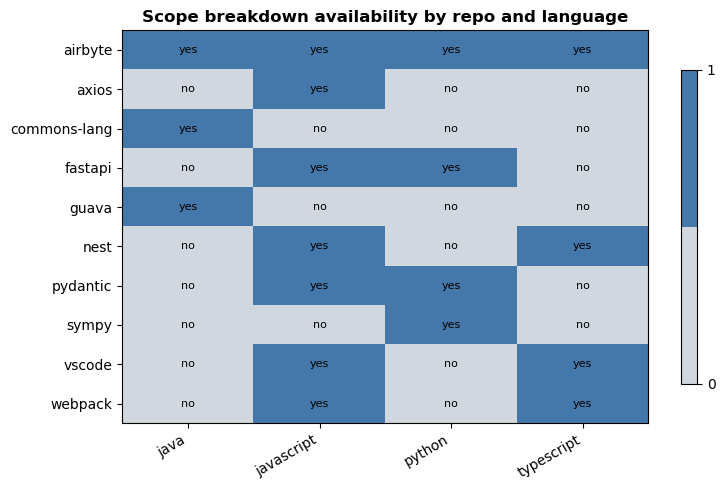

In [4]:
availability_matrix = scope_inventory_df.pivot(index="repo", columns="language", values="scope_breakdown_available")
availability_numeric = availability_matrix.eq(True).astype(int)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(availability_numeric.values, cmap=BOOLEAN_CMAP, vmin=0, vmax=1, aspect="auto")
ax.set_title("Scope breakdown availability by repo and language", fontweight="bold")
ax.set_xticks(range(len(availability_numeric.columns)))
ax.set_xticklabels(availability_numeric.columns, rotation=30, ha="right")
ax.set_yticks(range(len(availability_numeric.index)))
ax.set_yticklabels(availability_numeric.index)
for i in range(len(availability_numeric.index)):
    for j in range(len(availability_numeric.columns)):
        val = availability_numeric.iloc[i, j]
        label = "yes" if val == 1 else "no"
        ax.text(j, i, label, ha="center", va="center", fontsize=8, color="black")
plt.colorbar(im, ax=ax, ticks=[0, 1], shrink=0.8)
plt.tight_layout()
plt.show()


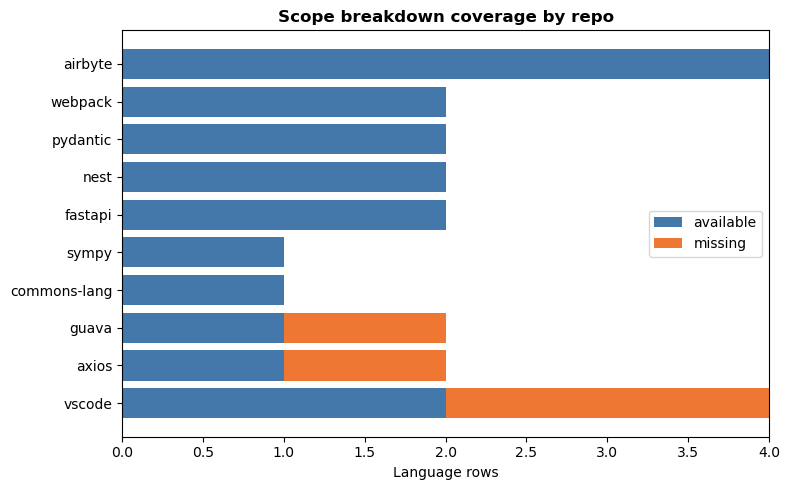

,repo,language,files,nodes,callsite_pairs,scope_breakdown_available
0,airbyte,java,473,4144,1568,True
1,airbyte,javascript,44,147,53,True
2,airbyte,python,2768,20976,12830,True
3,airbyte,typescript,3,8,2,True
4,axios,javascript,167,438,165,True
5,axios,typescript,6,138,0,False
6,commons-lang,java,534,11566,5718,True
7,fastapi,javascript,3,25,22,True
8,fastapi,python,1284,6579,694,True
9,guava,java,3243,64129,36099,True


In [5]:
coverage_counts = scope_inventory_df.groupby("repo").agg(
    available=("scope_breakdown_available", "sum"),
    missing=("scope_breakdown_available", lambda s: (~s).sum()),
).sort_values(["missing", "available"], ascending=[False, True])

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(coverage_counts.index, coverage_counts["available"], color="#4477AA", label="available")
ax.barh(coverage_counts.index, coverage_counts["missing"], left=coverage_counts["available"], color="#EE7733", label="missing")
ax.set_title("Scope breakdown coverage by repo", fontweight="bold")
ax.set_xlabel("Language rows")
ax.legend()
plt.tight_layout()
plt.show()

scope_inventory_df


## 2. Normalised flat tables

The notebook keeps three granularities:

- `repo_df`: one row per repository
- `lang_df`: one row per repository/language
- `scope_df`: one row per repository/language/scope, with explicit availability flags


In [6]:
def safe_div(num, den):
    den = np.nan if den in (0, None) else den
    return num / den if den == den else np.nan


def nullable_scope_metric(value, *, empty_scope):
    if value is None:
        return np.nan if empty_scope else np.nan
    return value


repo_rows = []
lang_rows = []
scope_rows = []
consistency_rows = []

for repo, report in reports.items():
    summary = report["summary"]
    totals = summary["totals"]
    density = totals["structural_density"]
    funnel = totals["call_site_funnel"]
    pair_expansion = totals["persisted_callsite_pair_expansion"]
    filter_buckets = totals["filtered_pre_persist_buckets"]
    phases = summary["build_phase_timings"]
    phase_sum = sum(phases.values())

    repo_rows.append({
        "repo": repo,
        "files": totals["files"],
        "nodes": totals["nodes"],
        "edges": totals["edges"],
        "nodes_per_file": density["nodes_per_file"],
        "eligible_callsites_per_file": density["eligible_callsites_per_file"],
        "low_node_file_ratio": density["low_node_file_ratio"],
        "observed_callsites": funnel["observed_syntactic_callsites"],
        "filtered_pre_persist": funnel["filtered_pre_persist"],
        "persisted_callsites": funnel["persisted_callsites"],
        "persisted_accepted": funnel["persisted_accepted"],
        "persisted_dropped": funnel["persisted_dropped"],
        "callsite_pairs": totals["callsite_pairs"]["count"],
        "finalized_call_edges": totals["finalized_call_edges"]["count"],
        "callsite_pairs_non_tests": totals["callsite_pairs_by_scope"]["non_tests"]["count"],
        "callsite_pairs_tests": totals["callsite_pairs_by_scope"]["tests"]["count"],
        "finalized_edges_non_tests": totals["finalized_call_edges_by_scope"]["non_tests"]["count"],
        "finalized_edges_tests": totals["finalized_call_edges_by_scope"]["tests"]["count"],
        "pair_expansion_factor": pair_expansion["pair_expansion_factor"],
        "multi_pair_share": pair_expansion["multi_pair_share"],
        "max_pairs_single_callsite": pair_expansion["max_pairs_for_single_persisted_callsite"],
        "persisted_zero_pair_share": safe_div(
            pair_expansion["persisted_callsites_with_zero_pairs"],
            pair_expansion["persisted_callsites"],
        ),
        "fpp_no_repo_terminal": filter_buckets["no_in_repo_candidate_terminal"],
        "fpp_no_repo_qualified": filter_buckets["no_in_repo_candidate_qualified"],
        "fpp_accepted_outside": filter_buckets["accepted_outside_in_repo"],
        "fpp_invalid_shape": filter_buckets["invalid_observation_shape"],
        "build_total_seconds": summary["build_total_seconds"],
        "build_wall_seconds": summary["build_wall_seconds"],
        "phase_accounted_seconds": phase_sum,
        "phase_accounted_share_of_build_total": safe_div(phase_sum, summary["build_total_seconds"]),
        "phase_accounted_share_of_build_wall": safe_div(phase_sum, summary["build_wall_seconds"]),
    })

    lang_sum_files = 0
    lang_sum_nodes = 0
    lang_sum_edges = 0
    lang_sum_pairs = 0
    lang_sum_finalized = 0

    for lang in summary["languages"]:
        lang_density = lang["structural_density"]
        lang_funnel = lang["call_site_funnel"]
        lang_pair_expansion = lang["persisted_callsite_pair_expansion"]
        lang_filter_buckets = lang.get("filtered_pre_persist_buckets", {})

        lang_rows.append({
            "repo": repo,
            "language": lang["language"],
            "files": lang["files"],
            "nodes": lang["nodes"],
            "edges": lang["edges"],
            "nodes_per_file": lang_density["nodes_per_file"],
            "eligible_callsites_per_file": lang_density["eligible_callsites_per_file"],
            "low_node_file_ratio": lang_density["low_node_file_ratio"],
            "observed_callsites": lang_funnel["observed_syntactic_callsites"],
            "filtered_pre_persist": lang_funnel["filtered_pre_persist"],
            "persisted_callsites": lang_funnel["persisted_callsites"],
            "persisted_accepted": lang_funnel["persisted_accepted"],
            "persisted_dropped": lang_funnel["persisted_dropped"],
            "callsite_pairs": lang["callsite_pairs"]["count"],
            "finalized_call_edges": lang["finalized_call_edges"]["count"],
            "pair_expansion_factor": lang_pair_expansion["pair_expansion_factor"],
            "multi_pair_share": lang_pair_expansion["multi_pair_share"],
            "max_pairs_single_callsite": lang_pair_expansion["max_pairs_for_single_persisted_callsite"],
            "persisted_zero_pair_share": safe_div(
                lang_pair_expansion["persisted_callsites_with_zero_pairs"],
                lang_pair_expansion["persisted_callsites"],
            ),
            "scope_breakdown_available": lang.get("call_site_funnel_by_scope") is not None,
            "fpp_no_repo_terminal": lang_filter_buckets.get("no_in_repo_candidate_terminal", 0),
            "fpp_no_repo_qualified": lang_filter_buckets.get("no_in_repo_candidate_qualified", 0),
            "fpp_accepted_outside": lang_filter_buckets.get("accepted_outside_in_repo", 0),
            "fpp_invalid_shape": lang_filter_buckets.get("invalid_observation_shape", 0),
        })

        lang_sum_files += lang["files"]
        lang_sum_nodes += lang["nodes"]
        lang_sum_edges += lang["edges"]
        lang_sum_pairs += lang["callsite_pairs"]["count"]
        lang_sum_finalized += lang["finalized_call_edges"]["count"]

        scope_funnel_map = lang.get("call_site_funnel_by_scope")
        scope_pair_map = lang.get("persisted_callsite_pair_expansion_by_scope")
        scope_callsite_pair_map = lang.get("callsite_pairs_by_scope")
        scope_edge_map = lang.get("finalized_call_edges_by_scope")
        scope_filter_bucket_map = lang.get("filtered_pre_persist_buckets_by_scope")

        if scope_funnel_map is None:
            for scope in ("non_tests", "tests"):
                scope_rows.append({
                    "repo": repo,
                    "language": lang["language"],
                    "scope": scope,
                    "scope_breakdown_available": False,
                    "empty_scope": False,
                    "files": lang["files"],
                    "observed_callsites": np.nan,
                    "filtered_pre_persist": np.nan,
                    "persisted_callsites": np.nan,
                    "persisted_accepted": np.nan,
                    "persisted_dropped": np.nan,
                    "callsite_pairs": np.nan,
                    "finalized_call_edges": np.nan,
                    "pair_expansion_factor": np.nan,
                    "multi_pair_share": np.nan,
                    "max_pairs_single_callsite": np.nan,
                    "fpp_total": np.nan,
                })
        else:
            for scope in ("non_tests", "tests"):
                scope_funnel = scope_funnel_map[scope]
                scope_pair_expansion = scope_pair_map[scope]
                scope_filter_buckets = (scope_filter_bucket_map or {}).get(scope, {})
                empty_scope = scope_pair_expansion["persisted_callsites"] == 0
                fpp_total = sum(scope_filter_buckets.values()) if scope_filter_buckets else 0
                scope_rows.append({
                    "repo": repo,
                    "language": lang["language"],
                    "scope": scope,
                    "scope_breakdown_available": True,
                    "empty_scope": empty_scope,
                    "files": lang["files"],
                    "observed_callsites": scope_funnel["observed_syntactic_callsites"],
                    "filtered_pre_persist": scope_funnel["filtered_pre_persist"],
                    "persisted_callsites": scope_funnel["persisted_callsites"],
                    "persisted_accepted": scope_funnel["persisted_accepted"],
                    "persisted_dropped": scope_funnel["persisted_dropped"],
                    "callsite_pairs": scope_callsite_pair_map[scope]["count"],
                    "finalized_call_edges": scope_edge_map[scope]["count"],
                    "pair_expansion_factor": nullable_scope_metric(scope_pair_expansion["pair_expansion_factor"], empty_scope=empty_scope),
                    "multi_pair_share": nullable_scope_metric(scope_pair_expansion["multi_pair_share"], empty_scope=empty_scope),
                    "max_pairs_single_callsite": scope_pair_expansion["max_pairs_for_single_persisted_callsite"],
                    "fpp_total": fpp_total,
                })

    repo_scope_filter_bucket_sum = 0
    scope_filter_bucket_map = totals.get("filtered_pre_persist_buckets_by_scope")
    if scope_filter_bucket_map is not None:
        for scope in ("non_tests", "tests"):
            repo_scope_filter_bucket_sum += sum(scope_filter_bucket_map[scope].values())

    consistency_rows.append({
        "repo": repo,
        "lang_sum_files_ok": lang_sum_files == totals["files"],
        "lang_sum_nodes_ok": lang_sum_nodes == totals["nodes"],
        "lang_sum_edges_ok": lang_sum_edges == totals["edges"],
        "lang_sum_callsite_pairs_ok": lang_sum_pairs == totals["callsite_pairs"]["count"],
        "lang_sum_finalized_edges_ok": lang_sum_finalized == totals["finalized_call_edges"]["count"],
        "funnel_conservation_ok": funnel["persisted_callsites"] == funnel["persisted_accepted"] + funnel["persisted_dropped"],
        "scope_funnel_observed_ok": totals["call_site_funnel_by_scope"]["non_tests"]["observed_syntactic_callsites"] + totals["call_site_funnel_by_scope"]["tests"]["observed_syntactic_callsites"] == funnel["observed_syntactic_callsites"],
        "scope_funnel_filtered_ok": totals["call_site_funnel_by_scope"]["non_tests"]["filtered_pre_persist"] + totals["call_site_funnel_by_scope"]["tests"]["filtered_pre_persist"] == funnel["filtered_pre_persist"],
        "scope_funnel_persisted_ok": totals["call_site_funnel_by_scope"]["non_tests"]["persisted_callsites"] + totals["call_site_funnel_by_scope"]["tests"]["persisted_callsites"] == funnel["persisted_callsites"],
        "scope_funnel_accepted_ok": totals["call_site_funnel_by_scope"]["non_tests"]["persisted_accepted"] + totals["call_site_funnel_by_scope"]["tests"]["persisted_accepted"] == funnel["persisted_accepted"],
        "scope_funnel_dropped_ok": totals["call_site_funnel_by_scope"]["non_tests"]["persisted_dropped"] + totals["call_site_funnel_by_scope"]["tests"]["persisted_dropped"] == funnel["persisted_dropped"],
        "scope_callsite_pairs_ok": totals["callsite_pairs_by_scope"]["non_tests"]["count"] + totals["callsite_pairs_by_scope"]["tests"]["count"] == totals["callsite_pairs"]["count"],
        "scope_finalized_edges_ok": totals["finalized_call_edges_by_scope"]["non_tests"]["count"] + totals["finalized_call_edges_by_scope"]["tests"]["count"] == totals["finalized_call_edges"]["count"],
        "filter_bucket_sum_ok": sum(filter_buckets.values()) == funnel["filtered_pre_persist"],
        "scope_filter_bucket_sum_ok": repo_scope_filter_bucket_sum == funnel["filtered_pre_persist"],
        "phase_sum_matches_build_total": np.isclose(phase_sum, summary["build_total_seconds"]),
        "phase_sum_matches_build_wall": np.isclose(phase_sum, summary["build_wall_seconds"]),
    })

repo_df = pd.DataFrame(repo_rows).set_index("repo").sort_index()
lang_df = pd.DataFrame(lang_rows).sort_values(["repo", "language"]).reset_index(drop=True)
scope_df = pd.DataFrame(scope_rows).sort_values(["repo", "language", "scope"]).reset_index(drop=True)
consistency_df = pd.DataFrame(consistency_rows).set_index("repo").sort_index()

for frame in (repo_df, lang_df, scope_df):
    frame["filter_rate"] = frame["filtered_pre_persist"] / frame["observed_callsites"]
    frame["drop_rate"] = frame["persisted_dropped"] / frame["persisted_callsites"].replace(0, np.nan)
    frame["funnel_yield"] = frame["persisted_accepted"] / frame["observed_callsites"]
    frame["edge_resolution_rate"] = frame["finalized_call_edges"] / frame["callsite_pairs"].replace(0, np.nan)

repo_df["test_callsite_pair_share"] = repo_df["callsite_pairs_tests"] / repo_df["callsite_pairs"].replace(0, np.nan)
repo_df["edge_to_node_ratio"] = repo_df["edges"] / repo_df["nodes"].replace(0, np.nan)
repo_df["fpp_total"] = repo_df[["fpp_no_repo_terminal", "fpp_no_repo_qualified", "fpp_accepted_outside", "fpp_invalid_shape"]].sum(axis=1)
repo_df["fpp_total_rate"] = repo_df["fpp_total"] / repo_df["observed_callsites"].replace(0, np.nan)
lang_df["edge_to_node_ratio"] = lang_df["edges"] / lang_df["nodes"].replace(0, np.nan)
lang_df["fpp_total"] = lang_df[["fpp_no_repo_terminal", "fpp_no_repo_qualified", "fpp_accepted_outside", "fpp_invalid_shape"]].sum(axis=1)
lang_df["fpp_total_rate"] = lang_df["fpp_total"] / lang_df["observed_callsites"].replace(0, np.nan)
scope_df["fpp_total_rate"] = scope_df["fpp_total"] / scope_df["observed_callsites"].replace(0, np.nan)

print("repo_df", repo_df.shape)
print("lang_df", lang_df.shape)
print("scope_df", scope_df.shape)
print("consistency_df", consistency_df.shape)


repo_df (10, 38)
lang_df (22, 31)
scope_df (44, 22)
consistency_df (10, 17)


## 3. Repository-level summary

These are descriptive totals. They do not imply any consistency result beyond what is checked later.


In [7]:
repo_summary_cols = [
    "files",
    "nodes",
    "edges",
    "observed_callsites",
    "filtered_pre_persist",
    "persisted_callsites",
    "persisted_accepted",
    "persisted_dropped",
    "callsite_pairs",
    "finalized_call_edges",
    "filter_rate",
    "drop_rate",
    "funnel_yield",
    "edge_resolution_rate",
    "test_callsite_pair_share",
    "pair_expansion_factor",
    "persisted_zero_pair_share",
    "build_total_seconds",
    "build_wall_seconds",
]
repo_df[repo_summary_cols].sort_values("callsite_pairs", ascending=False)


,files,nodes,edges,observed_callsites,filtered_pre_persist,persisted_callsites,persisted_accepted,persisted_dropped,callsite_pairs,finalized_call_edges,filter_rate,drop_rate,funnel_yield,edge_resolution_rate,test_callsite_pair_share,pair_expansion_factor,persisted_zero_pair_share,build_total_seconds,build_wall_seconds
repo,,,,,,,,,,,,,,,,,,,
vscode,6765,108097,171474,155451,10208,145243,141486,3757,176856,175171,0.0657,0.0259,0.9102,0.9905,0.1355,1.2177,0.0068,658.4365,665.1299
sympy,1590,40980,52633,72663,25344,47319,47109,210,47109,46558,0.3488,0.0044,0.6483,0.9883,0.5333,0.9956,0.0044,140.1543,142.2320
guava,3245,64131,67212,36639,1266,35373,34844,529,36099,36064,0.0346,0.0150,0.9510,0.9990,0.3298,1.0205,0.0050,98.9475,101.7128
airbyte,3288,25275,24450,15626,896,14730,14441,289,14453,13613,0.0573,0.0196,0.9242,0.9419,0.0419,0.9812,0.0192,59.8941,63.1584
commons-lang,534,11566,11603,5692,205,5487,5376,111,5718,5713,0.0360,0.0202,0.9445,0.9991,0.3587,1.0421,0.0077,17.8362,18.7037
webpack,8703,14945,11253,3368,156,3212,3135,77,3189,3175,0.0463,0.0240,0.9308,0.9956,0.1192,0.9928,0.0184,43.0807,45.3109
pydantic,407,13301,14019,3263,848,2415,2273,142,2273,2264,0.2599,0.0588,0.6966,0.9960,0.3405,0.9412,0.0588,17.2452,18.0347
nest,1708,6416,8005,2353,342,2011,1952,59,2203,2195,0.1453,0.0293,0.8296,0.9964,0.0032,1.0955,0.0070,12.9048,13.8438
fastapi,1287,6604,7038,2310,1078,1232,716,516,716,716,0.4667,0.4188,0.3100,1.0000,0.3673,0.5812,0.4188,10.4574,11.3878


In [8]:
repo_df[repo_summary_cols].agg(["mean", "median", "min", "max"]).T.sort_index()


,mean,median,min,max
build_total_seconds,106.1475,30.4585,2.5183,658.4365
build_wall_seconds,108.2626,32.0073,3.1120,665.1299
callsite_pairs,28878.1000,4453.5000,165.0000,176856.0000
drop_rate,0.0640,0.0241,0.0044,0.4188
edge_resolution_rate,0.9895,0.9958,0.9419,1.0000
edges,36832.9000,12811.0000,642.0000,171474.0000
files,2770.0000,1649.0000,173.0000,8703.0000
filter_rate,0.1746,0.1055,0.0346,0.4667
filtered_pre_persist,4040.9000,872.0000,66.0000,25344.0000
finalized_call_edges,28563.2000,4444.0000,163.0000,175171.0000


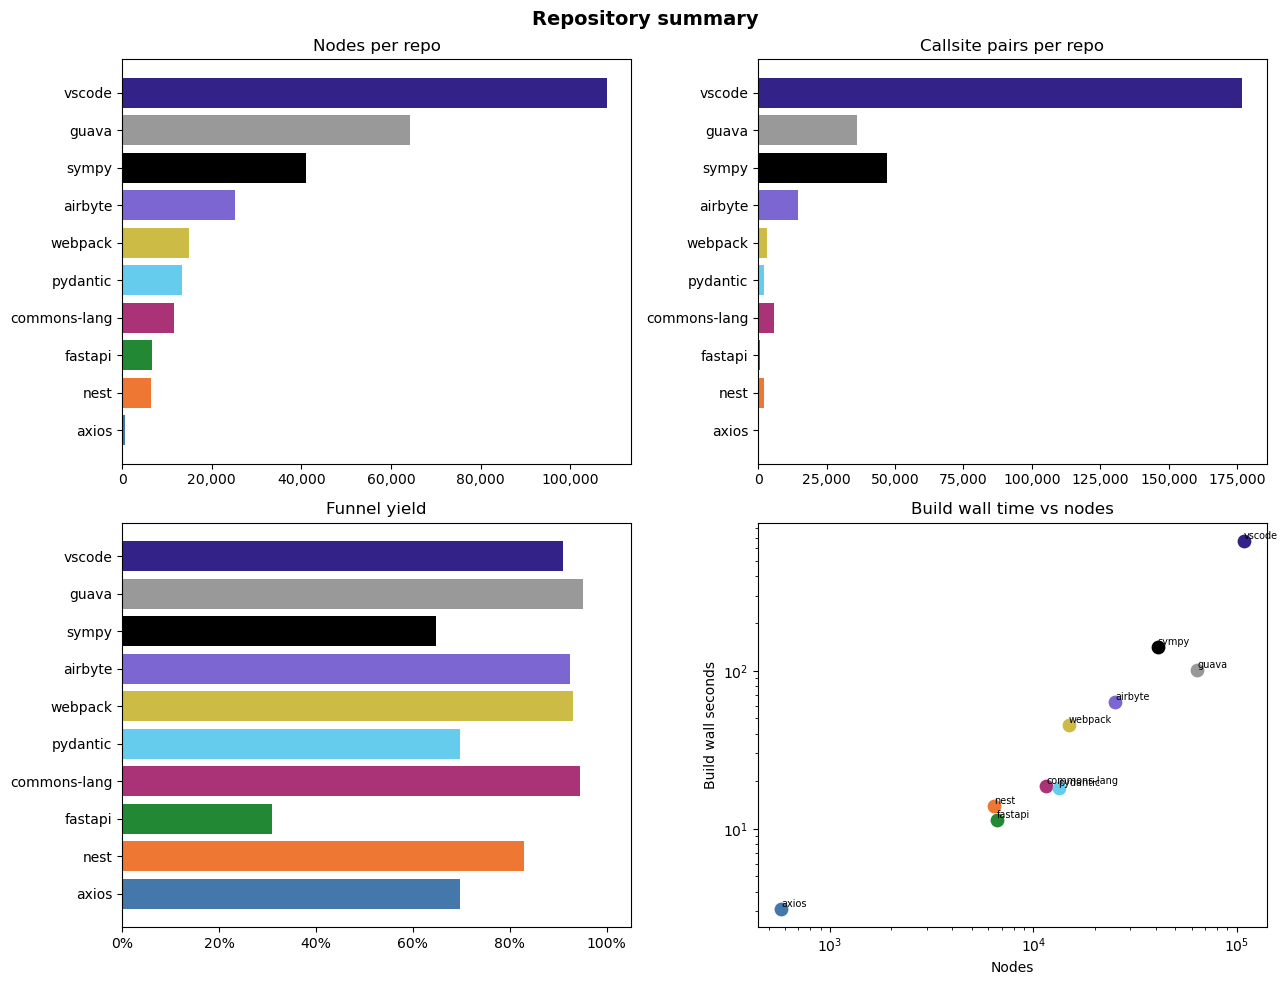

In [9]:
df = repo_df.sort_values("nodes")
colors = [PALETTE[i % len(PALETTE)] for i in range(len(df))]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Repository summary", fontsize=14, fontweight="bold")

axes[0, 0].barh(df.index, df["nodes"], color=colors)
axes[0, 0].set_title("Nodes per repo")
axes[0, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

axes[0, 1].barh(df.index, df["callsite_pairs"], color=colors)
axes[0, 1].set_title("Callsite pairs per repo")
axes[0, 1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

axes[1, 0].barh(df.index, df["funnel_yield"], color=colors)
axes[1, 0].set_title("Funnel yield")
axes[1, 0].set_xlim(0, 1.05)
axes[1, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))

for repo, row in df.iterrows():
    axes[1, 1].scatter(row["nodes"], row["build_wall_seconds"], color=PALETTE[df.index.get_loc(repo) % len(PALETTE)], s=80)
    axes[1, 1].annotate(repo, (row["nodes"], row["build_wall_seconds"]), fontsize=7, ha="left", va="bottom")
axes[1, 1].set_title("Build wall time vs nodes")
axes[1, 1].set_xlabel("Nodes")
axes[1, 1].set_ylabel("Build wall seconds")
axes[1, 1].set_xscale("log")
axes[1, 1].set_yscale("log")

plt.tight_layout()
plt.show()


## 4. Language-level summary

Language totals are aggregated from the repository/language rows. Coverage for scope-level analysis is shown separately in the next section.


In [10]:
language_summary = lang_df.groupby("language").agg(
    repo_count=("repo", "nunique"),
    row_count=("language", "size"),
    rows_with_scope_breakdown=("scope_breakdown_available", "sum"),
    files=("files", "sum"),
    nodes=("nodes", "sum"),
    callsite_pairs=("callsite_pairs", "sum"),
    finalized_call_edges=("finalized_call_edges", "sum"),
    mean_filter_rate=("filter_rate", "mean"),
    mean_drop_rate=("drop_rate", "mean"),
    mean_funnel_yield=("funnel_yield", "mean"),
    mean_edge_resolution_rate=("edge_resolution_rate", "mean"),
    mean_pair_expansion_factor=("pair_expansion_factor", "mean"),
    mean_low_node_file_ratio=("low_node_file_ratio", "mean"),
).sort_values("callsite_pairs", ascending=False)
language_summary


,repo_count,row_count,rows_with_scope_breakdown,files,nodes,callsite_pairs,finalized_call_edges,mean_filter_rate,mean_drop_rate,mean_funnel_yield,mean_edge_resolution_rate,mean_pair_expansion_factor,mean_low_node_file_ratio
language,,,,,,,,,,,,,
typescript,5,5,4,8412,114375,178948,177255,0.0528,0.0138,0.9349,0.9967,1.0784,0.3963
python,5,5,4,6046,81834,62898,61498,0.2852,0.1277,0.6418,0.9797,0.8723,0.1952
java,4,4,3,4251,79844,43385,43345,0.0346,0.0145,0.9514,0.9994,1.0207,0.0233
javascript,8,8,7,8991,15838,3550,3534,0.0486,0.0104,0.9422,0.9976,0.9978,0.5973


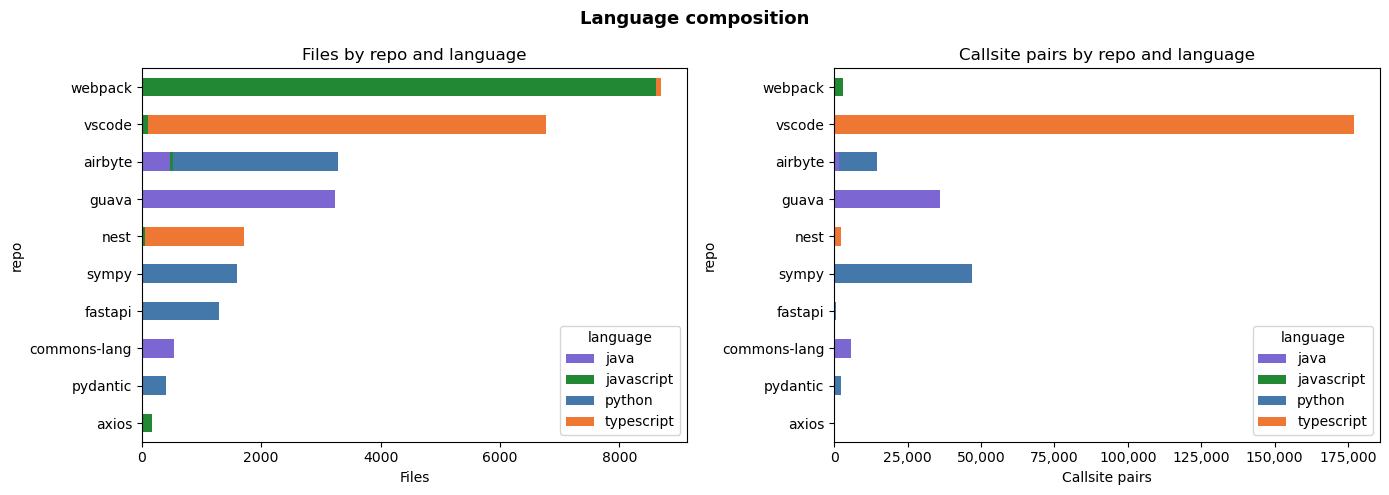

In [11]:
file_pivot = lang_df.pivot_table(index="repo", columns="language", values="files", aggfunc="sum").fillna(0)
callsite_pivot = lang_df.pivot_table(index="repo", columns="language", values="callsite_pairs", aggfunc="sum").fillna(0)
file_pivot = file_pivot.loc[file_pivot.sum(axis=1).sort_values().index]
callsite_pivot = callsite_pivot.loc[file_pivot.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Language composition", fontsize=13, fontweight="bold")

file_colors = [LANG_COLORS.get(lang, LANG_COLORS["other"]) for lang in file_pivot.columns]
callsite_colors = [LANG_COLORS.get(lang, LANG_COLORS["other"]) for lang in callsite_pivot.columns]

file_pivot.plot(kind="barh", stacked=True, ax=axes[0], color=file_colors)
axes[0].set_title("Files by repo and language")
axes[0].set_xlabel("Files")

callsite_pivot.plot(kind="barh", stacked=True, ax=axes[1], color=callsite_colors)
axes[1].set_title("Callsite pairs by repo and language")
axes[1].set_xlabel("Callsite pairs")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()


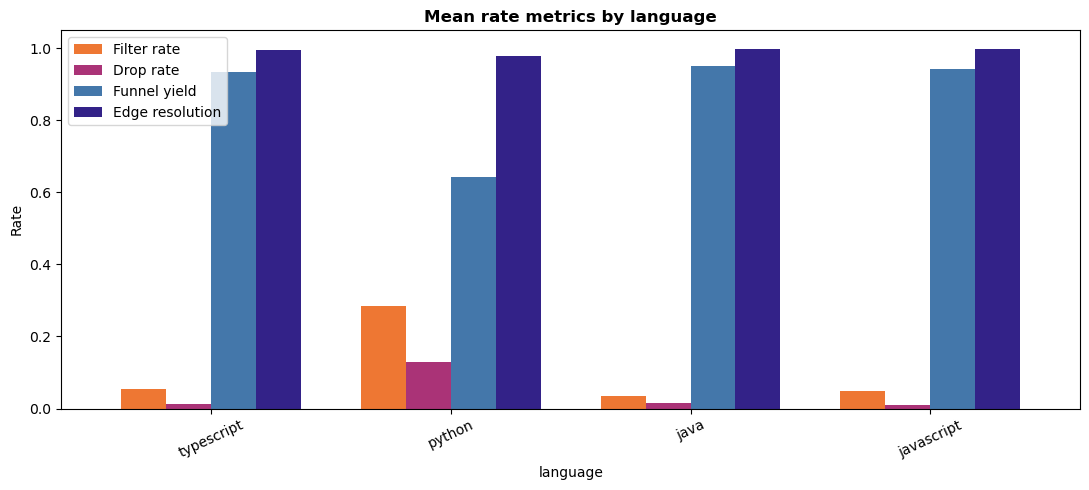

In [12]:
rate_cols = ["mean_filter_rate", "mean_drop_rate", "mean_funnel_yield", "mean_edge_resolution_rate"]
rate_labels = ["Filter rate", "Drop rate", "Funnel yield", "Edge resolution"]
rate_plot = language_summary[rate_cols].rename(columns=dict(zip(rate_cols, rate_labels)))
ax = rate_plot.plot(kind="bar", figsize=(11, 5), color=["#EE7733", "#AA3377", "#4477AA", "#332288"], width=0.75)
ax.set_title("Mean rate metrics by language", fontweight="bold")
ax.set_ylabel("Rate")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


## 5. Scope analysis with explicit coverage

Scope metrics are only computed from rows where scope breakdown exists. Counts below show the effective denominator for each language/scope combination.


In [13]:
scope_coverage = scope_df.groupby(["language", "scope"]).agg(
    rows_total=("repo", "size"),
    rows_with_scope_breakdown=("scope_breakdown_available", "sum"),
    rows_with_metric=("observed_callsites", lambda s: s.notna().sum()),
    empty_scope_rows=("empty_scope", "sum"),
).reset_index().sort_values(["language", "scope"])
scope_coverage


,language,scope,rows_total,rows_with_scope_breakdown,rows_with_metric,empty_scope_rows
0,java,non_tests,4,3,3,0
1,java,tests,4,3,3,0
2,javascript,non_tests,8,7,7,0
3,javascript,tests,8,7,7,3
4,python,non_tests,5,4,4,0
5,python,tests,5,4,4,0
6,typescript,non_tests,5,4,4,0
7,typescript,tests,5,4,4,2


In [14]:
scope_summary = scope_df[scope_df["scope_breakdown_available"]].groupby(["language", "scope"]).agg(
    repo_count=("repo", "nunique"),
    rows=("repo", "size"),
    empty_scope_rows=("empty_scope", "sum"),
    observed_callsites=("observed_callsites", "sum"),
    persisted_callsites=("persisted_callsites", "sum"),
    persisted_accepted=("persisted_accepted", "sum"),
    persisted_dropped=("persisted_dropped", "sum"),
    callsite_pairs=("callsite_pairs", "sum"),
    finalized_call_edges=("finalized_call_edges", "sum"),
    mean_filter_rate=("filter_rate", "mean"),
    mean_drop_rate=("drop_rate", "mean"),
    mean_funnel_yield=("funnel_yield", "mean"),
    mean_edge_resolution_rate=("edge_resolution_rate", "mean"),
    mean_pair_expansion_factor=("pair_expansion_factor", "mean"),
).reset_index().sort_values(["language", "scope"])
scope_summary


,language,scope,repo_count,rows,empty_scope_rows,observed_callsites,persisted_callsites,persisted_accepted,persisted_dropped,callsite_pairs,finalized_call_edges,mean_filter_rate,mean_drop_rate,mean_funnel_yield,mean_edge_resolution_rate,mean_pair_expansion_factor
0,java,non_tests,3,3,0,28118.0000,27884.0000,27360.0000,524.0000,28969.0000,28929.0000,0.0176,0.0171,0.9655,0.9991,1.0379
1,java,tests,3,3,0,15836.0000,14545.0000,14416.0000,129.0000,14416.0000,14416.0000,0.0595,0.0088,0.9325,1.0000,0.9912
2,javascript,non_tests,7,7,0,3353.0000,3136.0000,3064.0000,72.0000,3124.0000,3108.0000,0.0494,0.0087,0.9432,0.9975,1.0010
3,javascript,tests,7,7,3,444.0000,438.0000,426.0000,12.0000,426.0000,426.0000,0.0096,0.0196,0.9713,1.0000,0.9804
4,python,non_tests,4,4,0,44298.0000,37001.0000,36597.0000,404.0000,36597.0000,35700.0000,0.2060,0.0164,0.7806,0.9828,0.9836
5,python,tests,4,4,0,47856.0000,27041.0000,26301.0000,740.0000,26301.0000,25798.0000,0.3339,0.2025,0.5594,0.9922,0.7975
6,typescript,non_tests,4,4,0,135037.0000,125000.0000,121273.0000,3727.0000,155017.0000,153337.0000,0.0546,0.0148,0.9322,0.9964,1.0846
7,typescript,tests,4,4,2,22654.0000,22142.0000,22056.0000,86.0000,23931.0000,23918.0000,0.1224,0.0019,0.8757,0.9997,1.0404


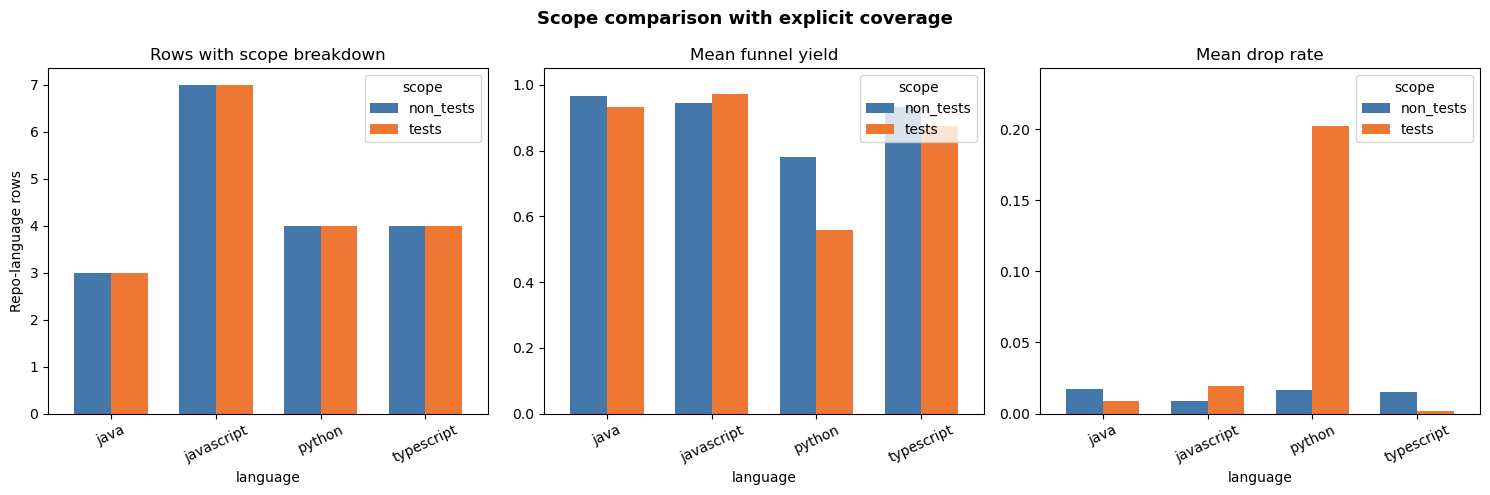

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Scope comparison with explicit coverage", fontsize=13, fontweight="bold")

coverage_pivot = scope_coverage.pivot(index="language", columns="scope", values="rows_with_scope_breakdown").fillna(0)
yield_pivot = scope_summary.pivot(index="language", columns="scope", values="mean_funnel_yield")
drop_pivot = scope_summary.pivot(index="language", columns="scope", values="mean_drop_rate")

coverage_pivot.plot(kind="bar", ax=axes[0], color=["#4477AA", "#EE7733"], width=0.7)
axes[0].set_title("Rows with scope breakdown")
axes[0].set_ylabel("Repo-language rows")
axes[0].tick_params(axis="x", rotation=25)

yield_pivot.plot(kind="bar", ax=axes[1], color=["#4477AA", "#EE7733"], width=0.7)
axes[1].set_title("Mean funnel yield")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=25)

drop_pivot.plot(kind="bar", ax=axes[2], color=["#4477AA", "#EE7733"], width=0.7)
axes[2].set_title("Mean drop rate")
drop_max = np.nanmax(drop_pivot.values) if np.isfinite(np.nanmax(drop_pivot.values)) else 0.0
axes[2].set_ylim(0, max(0.05, drop_max * 1.2))
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


## 6. Consistency and data-quality checks

This section separates arithmetic consistency from descriptive summaries.


In [16]:
consistency_df


,lang_sum_files_ok,lang_sum_nodes_ok,lang_sum_edges_ok,lang_sum_callsite_pairs_ok,lang_sum_finalized_edges_ok,funnel_conservation_ok,scope_funnel_observed_ok,scope_funnel_filtered_ok,scope_funnel_persisted_ok,scope_funnel_accepted_ok,scope_funnel_dropped_ok,scope_callsite_pairs_ok,scope_finalized_edges_ok,filter_bucket_sum_ok,scope_filter_bucket_sum_ok,phase_sum_matches_build_total,phase_sum_matches_build_wall
repo,,,,,,,,,,,,,,,,,
airbyte,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False,False
axios,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False,False
commons-lang,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False,False
fastapi,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False,False
guava,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False,False
nest,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False,False
pydantic,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False,False
sympy,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False,False
vscode,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False,False


In [17]:
consistency_failures = consistency_df.apply(lambda col: ~col)
consistency_failures.sum().sort_values(ascending=False)


phase_sum_matches_build_wall     10
phase_sum_matches_build_total    10
lang_sum_files_ok                 0
lang_sum_nodes_ok                 0
lang_sum_edges_ok                 0
funnel_conservation_ok            0
scope_funnel_observed_ok          0
lang_sum_callsite_pairs_ok        0
lang_sum_finalized_edges_ok       0
scope_funnel_persisted_ok         0
scope_funnel_filtered_ok          0
scope_funnel_accepted_ok          0
scope_funnel_dropped_ok           0
scope_finalized_edges_ok          0
scope_callsite_pairs_ok           0
scope_filter_bucket_sum_ok        0
filter_bucket_sum_ok              0
dtype: int64

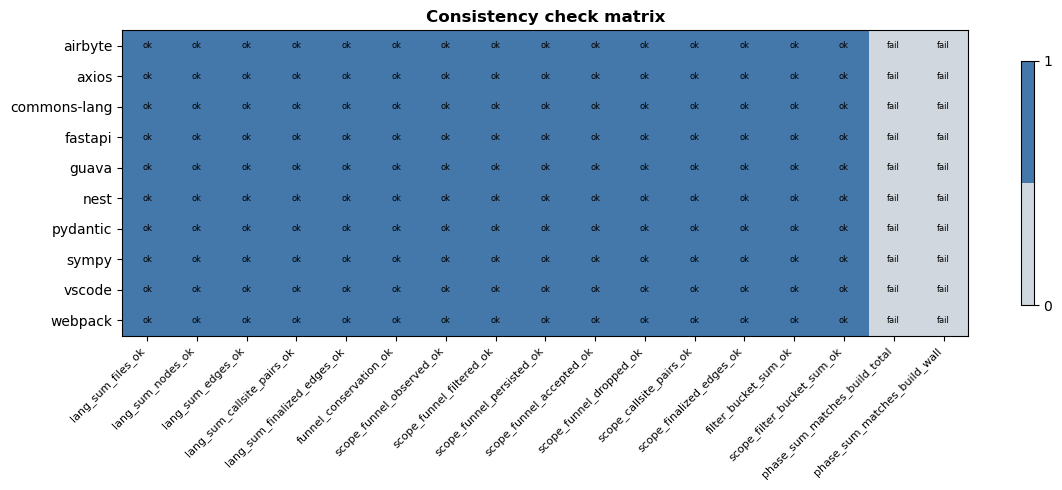

In [18]:
check_order = consistency_df.columns.tolist()
check_matrix = consistency_df[check_order].astype(int)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(check_matrix.values, cmap=BOOLEAN_CMAP, vmin=0, vmax=1, aspect="auto")
ax.set_title("Consistency check matrix", fontweight="bold")
ax.set_xticks(range(len(check_order)))
ax.set_xticklabels(check_order, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(check_matrix.index)))
ax.set_yticklabels(check_matrix.index)
for i in range(len(check_matrix.index)):
    for j in range(len(check_order)):
        val = check_matrix.iloc[i, j]
        ax.text(j, i, "ok" if val else "fail", ha="center", va="center", fontsize=6)
plt.colorbar(im, ax=ax, ticks=[0, 1], shrink=0.8)
plt.tight_layout()
plt.show()


In [19]:
repo_quality = pd.DataFrame({
    "scope_breakdown_missing_languages": inventory_df["languages_missing_scope_breakdown"],
    "filter_bucket_sum_ok": consistency_df["filter_bucket_sum_ok"],
    "scope_filter_bucket_sum_ok": consistency_df["scope_filter_bucket_sum_ok"],
    "phase_sum_matches_build_total": consistency_df["phase_sum_matches_build_total"],
    "phase_sum_matches_build_wall": consistency_df["phase_sum_matches_build_wall"],
    "phase_accounted_share_of_build_total": repo_df["phase_accounted_share_of_build_total"],
    "phase_accounted_share_of_build_wall": repo_df["phase_accounted_share_of_build_wall"],
}).sort_values(["scope_breakdown_missing_languages", "phase_accounted_share_of_build_total"], ascending=[False, True])
repo_quality


,scope_breakdown_missing_languages,filter_bucket_sum_ok,scope_filter_bucket_sum_ok,phase_sum_matches_build_total,phase_sum_matches_build_wall,phase_accounted_share_of_build_total,phase_accounted_share_of_build_wall
repo,,,,,,,
vscode,2,True,True,False,False,0.8771,0.8682
axios,1,True,True,False,False,0.7175,0.5806
guava,1,True,True,False,False,0.7465,0.7262
fastapi,0,True,True,False,False,0.7951,0.7302
nest,0,True,True,False,False,0.8075,0.7528
airbyte,0,True,True,False,False,0.8101,0.7682
webpack,0,True,True,False,False,0.8130,0.7730
commons-lang,0,True,True,False,False,0.8141,0.7764
pydantic,0,True,True,False,False,0.8271,0.7908


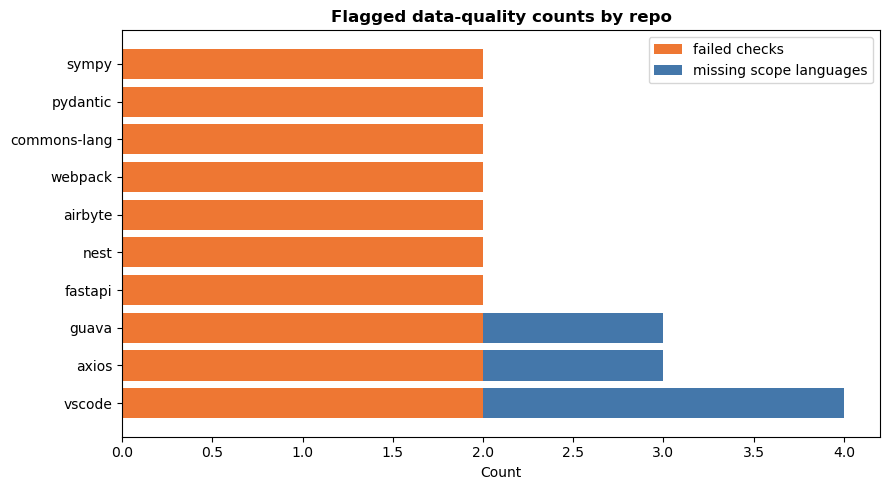

In [20]:
flag_matrix = pd.DataFrame({
    "missing_scope_languages": inventory_df["languages_missing_scope_breakdown"],
    "failed_checks": consistency_failures.sum(axis=1),
    "phase_gap_total": 1 - repo_df["phase_accounted_share_of_build_total"],
    "phase_gap_wall": 1 - repo_df["phase_accounted_share_of_build_wall"],
}).sort_values(["failed_checks", "missing_scope_languages", "phase_gap_total"], ascending=[False, False, False])

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(flag_matrix.index, flag_matrix["failed_checks"], color="#EE7733", label="failed checks")
ax.barh(flag_matrix.index, flag_matrix["missing_scope_languages"], left=flag_matrix["failed_checks"], color="#4477AA", label="missing scope languages")
ax.set_title("Flagged data-quality counts by repo", fontweight="bold")
ax.set_xlabel("Count")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Build timing analysis

`build_total_seconds` and `build_wall_seconds` are report-level timings. The sum of `build_phase_timings` is analysed separately as accounted phase time because it is not equal to either total in these reports.


In [21]:
phase_rows = []
for repo, report in reports.items():
    for phase, seconds in report["summary"]["build_phase_timings"].items():
        phase_rows.append({"repo": repo, "phase": phase, "seconds": seconds})

phase_df = pd.DataFrame(phase_rows)
phase_summary = phase_df.pivot(index="repo", columns="phase", values="seconds").fillna(0).sort_index()
phase_summary["phase_accounted_seconds"] = phase_summary.sum(axis=1)
phase_summary["build_total_seconds"] = repo_df["build_total_seconds"]
phase_summary["build_wall_seconds"] = repo_df["build_wall_seconds"]
phase_summary["phase_accounted_share_of_build_total"] = repo_df["phase_accounted_share_of_build_total"]
phase_summary["phase_accounted_share_of_build_wall"] = repo_df["phase_accounted_share_of_build_wall"]
phase_summary


phase,build_structural_index,compute_build_fingerprint,derive_call_artifacts,discover_files,prepare_callsite_pairs,prepare_snapshots,rebuild_graph_index,rebuild_graph_rollups,register_modules,write_callsite_pairs,phase_accounted_seconds,build_total_seconds,build_wall_seconds,phase_accounted_share_of_build_total,phase_accounted_share_of_build_wall
repo,,,,,,,,,,,,,,,
airbyte,21.5154,0.5394,19.2703,2.2190,0.8683,0.5903,0.8103,0.8550,1.2609,0.5889,48.5178,59.8941,63.1584,0.8101,0.7682
axios,0.6762,0.2187,0.6294,0.1754,0.0085,0.0271,0.0078,0.0089,0.0504,0.0044,1.8068,2.5183,3.1120,0.7175,0.5806
commons-lang,6.8235,0.2667,5.7021,0.3331,0.2712,0.1227,0.2680,0.3192,0.2043,0.2100,14.5207,17.8362,18.7037,0.8141,0.7764
fastapi,3.6369,0.2551,2.8675,0.5053,0.1269,0.2667,0.1156,0.1202,0.3852,0.0355,8.3150,10.4574,11.3878,0.7951,0.7302
guava,34.2233,0.4444,26.6527,1.1240,1.9888,0.6469,2.5691,2.4725,1.3353,2.4100,73.8672,98.9475,101.7128,0.7465,0.7262
nest,4.3780,0.2617,3.9115,0.5520,0.1655,0.2861,0.1352,0.1492,0.5246,0.0573,10.4211,12.9048,13.8438,0.8075,0.7528
pydantic,7.1265,0.2749,5.6274,0.2722,0.1409,0.0810,0.2518,0.2749,0.1367,0.0763,14.2627,17.2452,18.0347,0.8271,0.7908
sympy,40.4138,0.3488,38.6184,0.6810,35.1633,0.3205,2.1415,1.6407,0.5778,2.8627,122.7686,140.1543,142.2320,0.8760,0.8632
vscode,132.7606,0.6581,119.4211,2.6406,286.6479,1.3542,10.0781,6.6486,2.8365,14.4400,577.4858,658.4365,665.1299,0.8771,0.8682


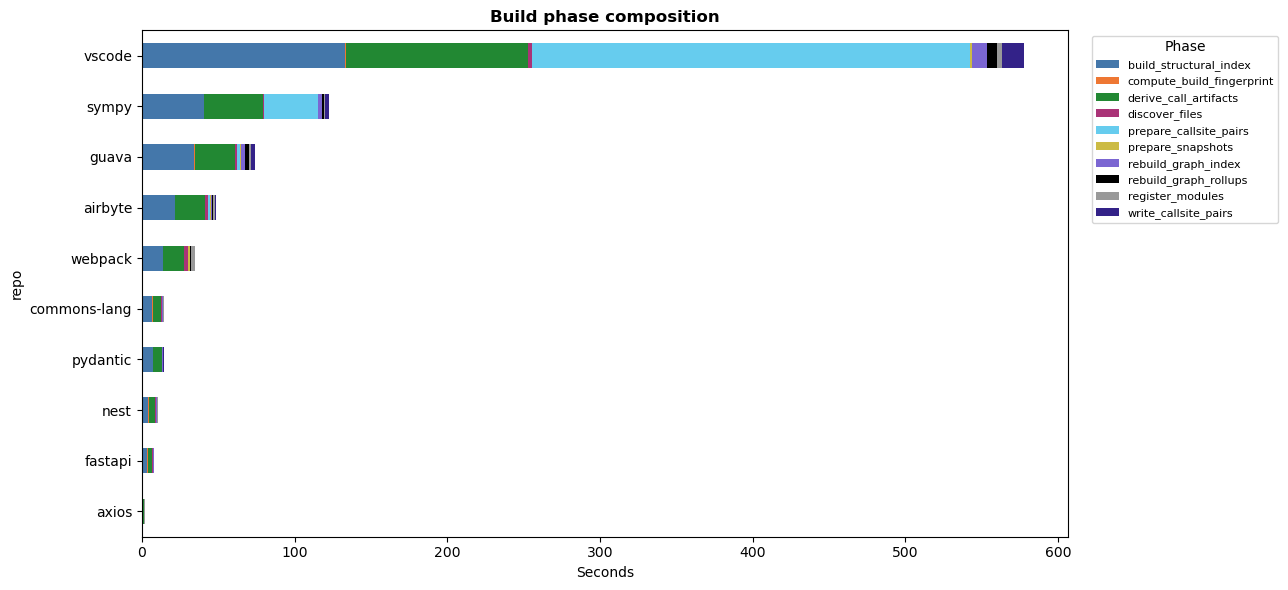

In [22]:
phase_cols = [c for c in phase_summary.columns if c not in {"phase_accounted_seconds", "build_total_seconds", "build_wall_seconds", "phase_accounted_share_of_build_total", "phase_accounted_share_of_build_wall"}]
phase_plot = phase_summary.sort_values("build_total_seconds", ascending=True)[phase_cols]
ax = phase_plot.plot(kind="barh", stacked=True, figsize=(13, 6), color=PALETTE[:len(phase_cols)])
ax.set_title("Build phase composition", fontweight="bold")
ax.set_xlabel("Seconds")
ax.legend(title="Phase", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


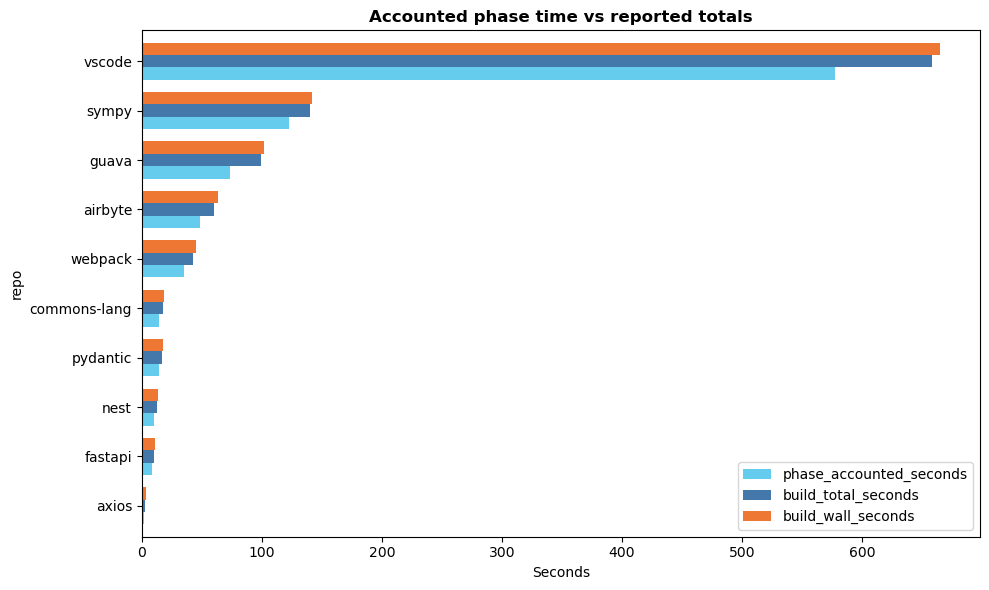

In [23]:
compare_df = repo_df[["phase_accounted_seconds", "build_total_seconds", "build_wall_seconds"]].sort_values("build_total_seconds")
ax = compare_df.plot(kind="barh", figsize=(10, 6), color=["#66CCEE", "#4477AA", "#EE7733"], width=0.75)
ax.set_title("Accounted phase time vs reported totals", fontweight="bold")
ax.set_xlabel("Seconds")
plt.tight_layout()
plt.show()


## 8. Focused findings tables

These tables are intended for direct review rather than further interpretation.


In [24]:
highest_filter = repo_df[["filtered_pre_persist", "observed_callsites", "filter_rate", "fpp_total", "fpp_total_rate"]].sort_values("filter_rate", ascending=False)
highest_filter


,filtered_pre_persist,observed_callsites,filter_rate,fpp_total,fpp_total_rate
repo,,,,,
fastapi,1078,2310,0.4667,1078,0.4667
sympy,25344,72663,0.3488,25344,0.3488
axios,66,231,0.2857,66,0.2857
pydantic,848,3263,0.2599,848,0.2599
nest,342,2353,0.1453,342,0.1453
vscode,10208,155451,0.0657,10208,0.0657
airbyte,896,15626,0.0573,896,0.0573
webpack,156,3368,0.0463,156,0.0463
commons-lang,205,5692,0.0360,205,0.0360


In [25]:
highest_drop = repo_df[["persisted_callsites", "persisted_dropped", "drop_rate", "pair_expansion_factor", "persisted_zero_pair_share"]].sort_values("drop_rate", ascending=False)
highest_drop


,persisted_callsites,persisted_dropped,drop_rate,pair_expansion_factor,persisted_zero_pair_share
repo,,,,,
fastapi,1232,516,0.4188,0.5812,0.4188
pydantic,2415,142,0.0588,0.9412,0.0588
nest,2011,59,0.0293,1.0955,0.0070
vscode,145243,3757,0.0259,1.2177,0.0068
axios,165,4,0.0242,1.0000,0.0121
webpack,3212,77,0.0240,0.9928,0.0184
commons-lang,5487,111,0.0202,1.0421,0.0077
airbyte,14730,289,0.0196,0.9812,0.0192
guava,35373,529,0.0150,1.0205,0.0050


In [26]:
sparsity_and_density = repo_df[["files", "nodes_per_file", "eligible_callsites_per_file", "edge_to_node_ratio", "low_node_file_ratio"]].sort_values("low_node_file_ratio", ascending=False)
sparsity_and_density


,files,nodes_per_file,eligible_callsites_per_file,edge_to_node_ratio,low_node_file_ratio
repo,,,,,
webpack,8703,1.7172,0.3664,0.7530,0.8373
axios,173,3.3295,0.9538,1.1146,0.5491
nest,1708,3.7564,1.2898,1.2477,0.3126
airbyte,3288,7.6870,4.3957,0.9674,0.2232
vscode,6765,15.9789,26.1428,1.5863,0.2229
fastapi,1287,5.1313,0.5563,1.0657,0.1639
sympy,1590,25.7736,29.6283,1.2844,0.1371
pydantic,407,32.6806,5.5848,1.0540,0.0885
commons-lang,534,21.6592,10.7079,1.0032,0.0487


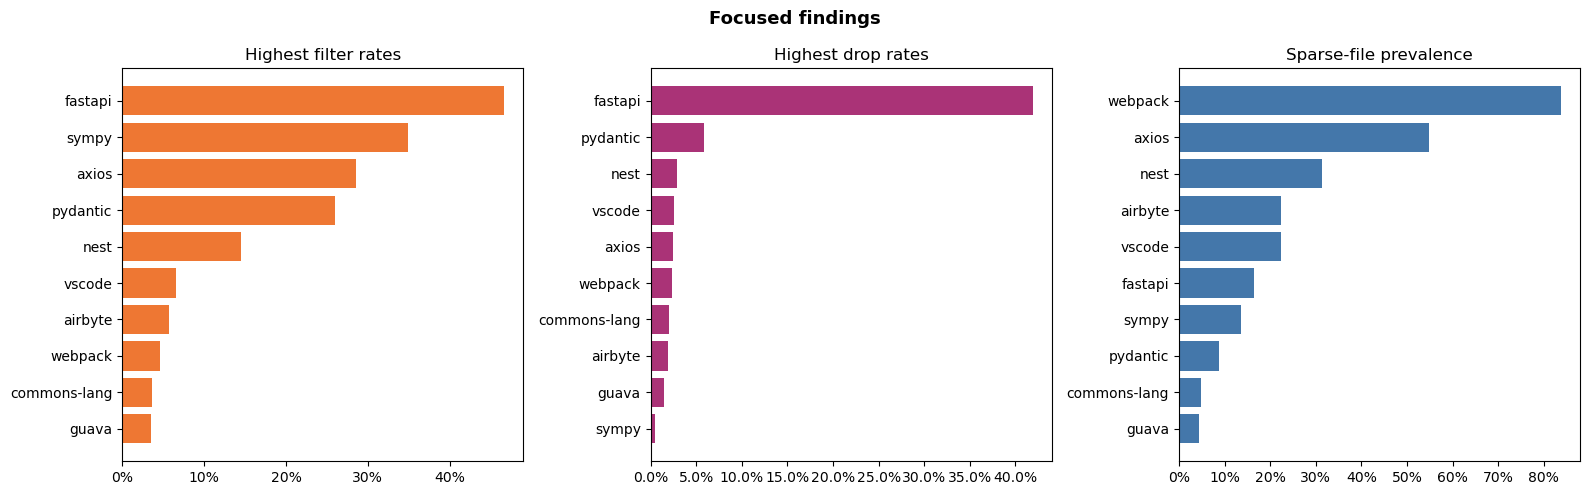

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Focused findings", fontsize=13, fontweight="bold")

filter_rank = repo_df.sort_values("filter_rate", ascending=True)
axes[0].barh(filter_rank.index, filter_rank["filter_rate"], color="#EE7733")
axes[0].set_title("Highest filter rates")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))

drop_rank = repo_df.sort_values("drop_rate", ascending=True)
axes[1].barh(drop_rank.index, drop_rank["drop_rate"], color="#AA3377")
axes[1].set_title("Highest drop rates")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1%}"))

sparse_rank = repo_df.sort_values("low_node_file_ratio", ascending=True)
axes[2].barh(sparse_rank.index, sparse_rank["low_node_file_ratio"], color="#4477AA")
axes[2].set_title("Sparse-file prevalence")
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))

plt.tight_layout()
plt.show()
